In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.stats import norm


In [2]:
a1 = -0.75
b1 = -0.25
a2 = 0.25
b2 = 0.75
eps = 0.01
T = 1
yt = 0

In [3]:
def fn(x):
    A = 0.5 / np.abs(b1 - a1) * (x<=b1) * (x>=a1) + 0.5 / np.abs(b2 - a2) * (x<=b2) * (x>=a2)
    B = 1 / np.sqrt(2*np.pi*eps*T) * np.exp(-1/2/eps/T*(yt-x)**2)
    C1 = 1 / np.abs(b1 - a1) * (norm.cdf((yt - a1) / np.sqrt(eps*T)) - norm.cdf((yt - b1) / np.sqrt(eps*T)))
    C2 = 1 / np.abs(b2 - a2) * (norm.cdf((yt - a2) / np.sqrt(eps*T)) - norm.cdf((yt - b2) / np.sqrt(eps*T)))
    
    return A * B / (0.5 * C1 + 0.5 * C2)


def s(Y, t):
    A1 = np.exp(-1/2/eps/t*(Y - a1) ** 2) - np.exp(-1/2/eps/t*(Y-b1) ** 2)
    A2 = np.exp(-1/2/eps/t*(Y - a2) ** 2) - np.exp(-1/2/eps/t*(Y-b2) ** 2)
    B1 = norm.cdf((Y - a1)/np.sqrt(eps*t)) - norm.cdf((Y - b1)/np.sqrt(eps*t))
    B2 = norm.cdf((Y - a2)/np.sqrt(eps*t)) - norm.cdf((Y - b2)/np.sqrt(eps*t))
    
    return np.sqrt(eps/2/np.pi/t) * (A1 + A2) / (B1 + B2)

In [20]:
samples = sio.loadmat("./sgm_1.mat")["zt"]

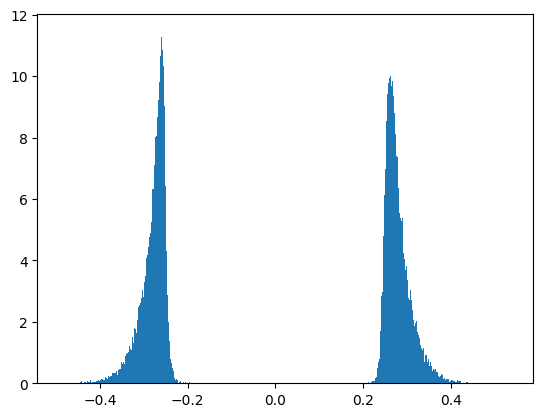

In [21]:
plt.hist(samples.flatten(), bins=1000, density=True)
plt.show()

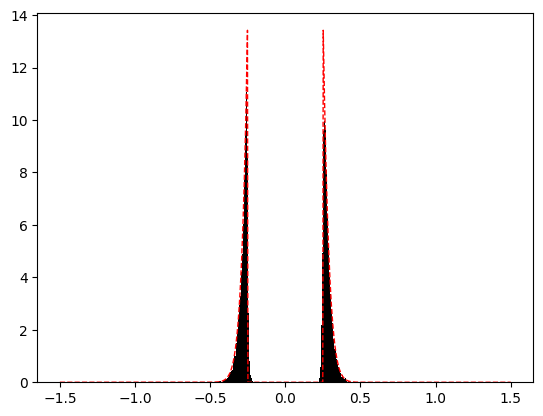

In [22]:
x = np.linspace(-1.5, 1.5, 1001)

plt.hist(samples.flatten(), bins=1000, color="k", density=True)
plt.plot(x, fn(x), "r--", label="exact density", linewidth=1)
plt.show()

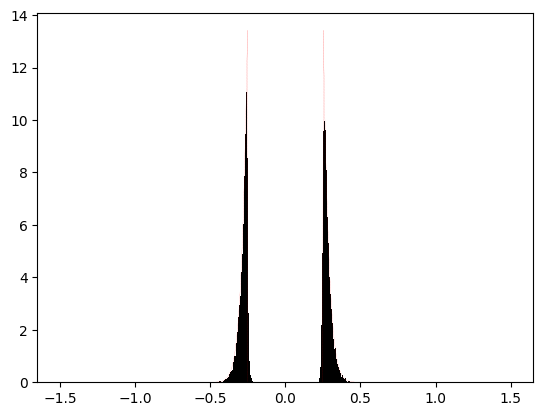

In [23]:
x = np.linspace(-1.5, 1.5, 1001)

plt.hist(samples.flatten(), bins=1000, color="k", density=True)
plt.plot(x, fn(x), "r--", label="exact density", linewidth=0.1)
plt.show()